# Análise Exploratória: Estratégia Wide Table

Este notebook explora as tabelas consolidadas (Wide Tables) de Corrida e Treino.
Objetivo: Validar se as métricas agregadas (ex: Ritmo de Treino) têm correlação com o Resultado da Corrida.

## 1. Configuração e Carregamento

In [1]:
%pip install pandas seaborn matplotlib s3fs python-dotenv boto3 pyarrow
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
BUCKET = os.environ.get('S3_BUCKET_NAME')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# --- CONFIGURAÇÃO ---
RACE_TABLE = "gold_race_wt"
PRACTICE_TABLE = "gold_practice_wt"

def load_table(name):
    try:
        print(f"Carregando {name}...")
        df = pd.read_parquet(f"s3://{BUCKET}/gold/{name}/")
        print(f"-> Carregado: {df.shape}")
        return df
    except Exception as e:
        print(f"Erro: {e}")
        return None

df_race = load_table(RACE_TABLE)
df_practice = load_table(PRACTICE_TABLE)

Note: you may need to restart the kernel to use updated packages.
Carregando gold_race_wt...
-> Carregado: (1176, 37)
Carregando gold_practice_wt...
-> Carregado: (3192, 37)


## 2. Análise da Tabela de Corrida (Alvo)
Vamos ver como as variáveis da corrida (ex: Grid, Pit Stops, Temperatura) se relacionam com a Posição Final.

,meeting_key,session_key,driver_number,grid_position,final_position,country_name,circuit_short_name,session_name,session_type,date_start,date_end,total_laps_completed,best_lap_time,avg_lap_time,std_lap_time,avg_lap_first_10,avg_lap_last_10,avg_position,position_after_lap_1,pct_laps_top10,num_pit_stops,avg_pit_duration,total_pit_time,num_stints,first_stint_compound,laps_on_soft,laps_on_medium,laps_on_hard,laps_on_wet,avg_track_temp,max_track_temp,min_track_temp,avg_air_temp,avg_humidity,avg_wind_speed,rain_flag,year
0,1215,9133,24,5.0,16,Hungary,Hungaroring,Race,Race,2023-07-23T13:00:00+00:00,2023-07-23T15:00:00+00:00,69,83.743,86.064588,4.053106,86.640778,84.7549,15.362319,5,0.014493,2,26.00,52.0,3,MEDIUM,0,10,59,0,48.579268,51.4,45.5,28.808537,32.804878,1.440854,0,2023
1,1215,9133,77,7.0,12,Hungary,Hungaroring,Race,Race,2023-07-23T13:00:00+00:00,2023-07-23T15:00:00+00:00,69,83.651,85.639338,3.415862,88.386444,84.2255,11.623188,7,0.217391,2,22.65,45.3,3,MEDIUM,0,9,60,0,48.579268,51.4,45.5,28.808537,32.804878,1.440854,0,2023
2,1215,9133,3,13.0,13,Hungary,Hungaroring,Race,Race,2023-07-23T13:00:00+00:00,2023-07-23T15:00:00+00:00,69,83.934,85.687853,3.367284,86.492333,84.4803,14.666667,13,0.043478,2,22.05,44.1,3,MEDIUM,0,58,11,0,48.579268,51.4,45.5,28.808537,32.804878,1.440854,0,2023


['meeting_key', 'session_key', 'driver_number', 'grid_position', 'final_position', 'country_name', 'circuit_short_name', 'session_name', 'session_type', 'date_start', 'date_end', 'total_laps_completed', 'best_lap_time', 'avg_lap_time', 'std_lap_time', 'avg_lap_first_10', 'avg_lap_last_10', 'avg_position', 'position_after_lap_1', 'pct_laps_top10', 'num_pit_stops', 'avg_pit_duration', 'total_pit_time', 'num_stints', 'first_stint_compound', 'laps_on_soft', 'laps_on_medium', 'laps_on_hard', 'laps_on_wet', 'avg_track_temp', 'max_track_temp', 'min_track_temp', 'avg_air_temp', 'avg_humidity', 'avg_wind_speed', 'rain_flag', 'year']


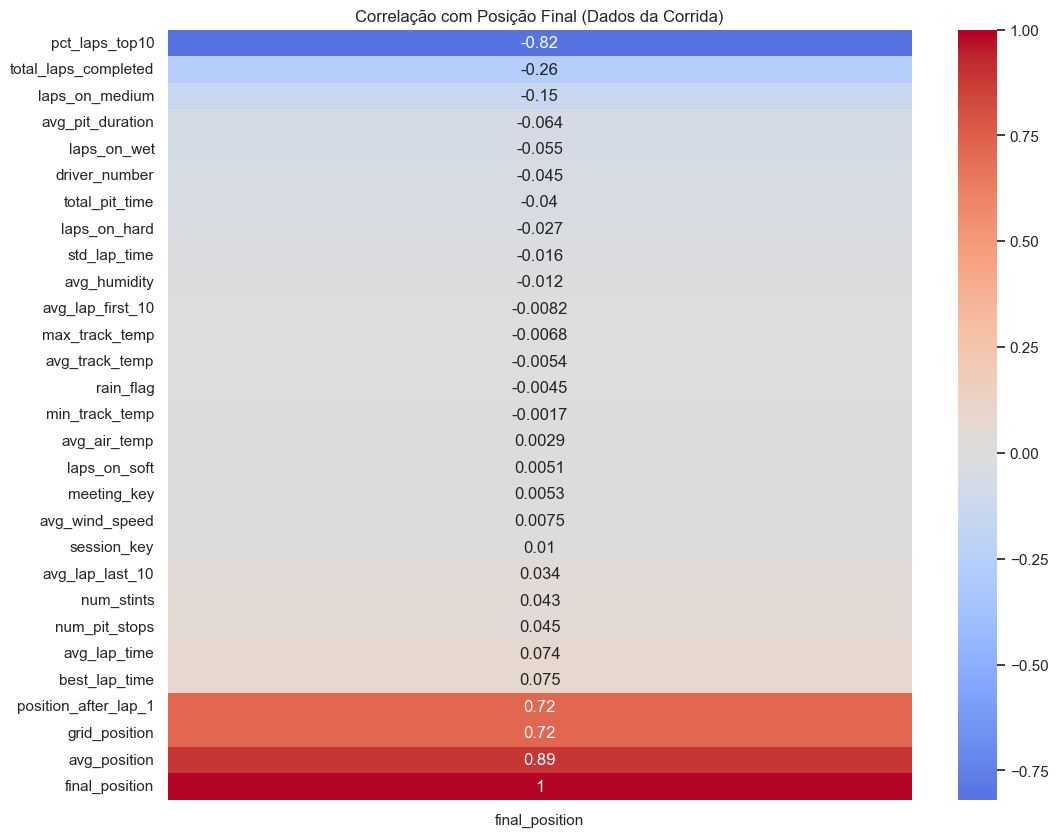

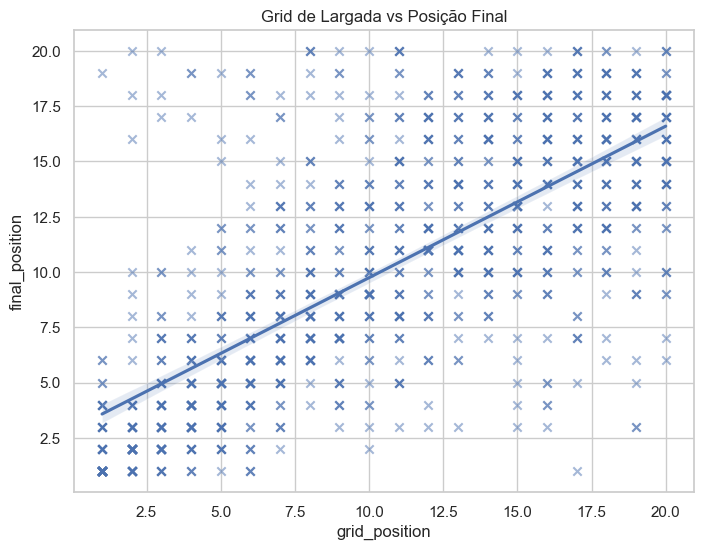

In [2]:
if df_race is not None:
    # 1. Info básica
    display(df_race.head(3))
    print(df_race.columns.tolist())
    
    # 2. Correlação (apenas numéricas)
    numeric_cols = df_race.select_dtypes(include=[np.number]).columns
    corr = df_race[numeric_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr[['final_position']].sort_values(by='final_position'), annot=True, cmap='coolwarm', center=0)
    plt.title("Correlação com Posição Final (Dados da Corrida)")
    plt.show()
    
    # 3. Grid vs Final
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df_race, x='grid_position', y='final_position', marker='x', scatter_kws={'alpha':0.5})
    plt.title("Grid de Largada vs Posição Final")
    plt.show()
else:
    print("Tabela de corrida não carregada.")

## 3. Análise Cruzada: Treino vs Corrida
A parte mais importante: O ritmo de treino (Practice) prevê a corrida?

Dados cruzados (Pilotos com dados em ambos): (2802, 72)


/Users/italorufca/Desktop/Italo/Projetos/pitwall-preditivo-f1/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/italorufca/Desktop/Italo/Projetos/pitwall-preditivo-f1/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/italorufca/Desktop/Italo/Projetos/pitwall-preditivo-f1/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


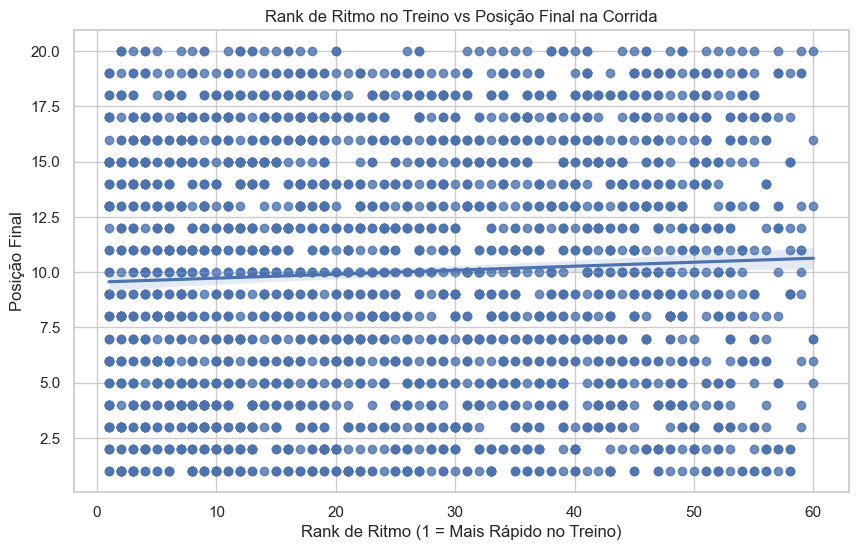

Correlação Rank Treino vs Final:                     practice_pace_rank  final_position
practice_pace_rank            1.000000        0.053185
final_position                0.053185        1.000000


In [3]:
if df_race is not None and df_practice is not None:
    # Renomear colunas de prática para o join e visualização
    # Ex: avg_lap_time (treino) vs avg_lap_time (corrida)
    cols_to_rename = {c: f"practice_{c}" for c in df_practice.columns if c not in ['meeting_key', 'driver_number']}
    df_p_clean = df_practice.rename(columns=cols_to_rename)
    
    # Join
    df_merged = pd.merge(df_race, df_p_clean, on=['meeting_key', 'driver_number'], how='inner')
    print(f"Dados cruzados (Pilotos com dados em ambos): {df_merged.shape}")
    
    # Scatter: Tempo Médio de Treino vs Posição Final
    # (Atenção: Tempos variam por pista, então olhar globalmente pode ser ruidoso sem normalizar,
    #  mas a correlação linear deve aparecer se o ritmo ditar resultado)
    
    if 'practice_avg_lap_time' in df_merged.columns:
        plt.figure(figsize=(10, 6))
        # Vamos filtrar outliers de tempo par não distorcer o gráfico (ex: tempo > 150s)
        # Ou melhor, vamos fazer por rank dentro da corrida para ser justo entre pistas diferentes
        
        # Criar Rank de Ritmo no Treino
        df_merged['practice_pace_rank'] = df_merged.groupby('meeting_key')['practice_avg_lap_time'].rank()
        
        sns.regplot(data=df_merged, x='practice_pace_rank', y='final_position')
        plt.title("Rank de Ritmo no Treino vs Posição Final na Corrida")
        plt.xlabel("Rank de Ritmo (1 = Mais Rápido no Treino)")
        plt.ylabel("Posição Final")
        plt.show()
        
        print("Correlação Rank Treino vs Final:", df_merged[['practice_pace_rank', 'final_position']].corr())
    else:
        print("Coluna 'practice_avg_lap_time' não encontrada.")
        print("Colunas disponíveis:", [c for c in df_merged.columns if 'practice' in c])

else:
    print("Dados insuficientes para análise cruzada.")